In [3]:
import pandas as pd
import numpy as np

In [5]:
student_performance=pd.read_csv("student-por.csv")

In [7]:
#student_stress=pd.read_csv("Stress Dataset.csv")

In [9]:
#student_stress.sample(10)

In [11]:
student_performance.sample(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
641,MS,F,18,R,GT3,T,2,2,at_home,other,...,5,3,3,1,3,4,0,14,17,15
10,GP,F,15,U,GT3,T,4,4,teacher,health,...,3,3,3,1,2,2,2,14,14,14
170,GP,F,18,R,GT3,T,1,1,at_home,other,...,5,2,5,1,5,4,6,11,10,11
108,GP,M,15,R,GT3,T,4,4,other,other,...,1,3,5,3,5,1,8,12,10,11
535,MS,M,15,R,GT3,T,1,2,other,services,...,5,5,5,1,3,5,11,9,11,10


In [13]:
student_performance=student_performance.drop(columns=["school","address","famsize","Pstatus","guardian","nursery","Dalc","Walc","reason"])

In [15]:
student_performance.head()

,sex,age,Medu,Fedu,Mjob,Fjob,traveltime,studytime,failures,schoolsup,...,internet,romantic,famrel,freetime,goout,health,absences,G1,G2,G3
0,F,18,4,4,at_home,teacher,2,2,0,yes,...,no,no,4,3,4,3,4,0,11,11
1,F,17,1,1,at_home,other,1,2,0,no,...,yes,no,5,3,3,3,2,9,11,11
2,F,15,1,1,at_home,other,1,2,0,yes,...,yes,no,4,3,2,3,6,12,13,12
3,F,15,4,2,health,services,1,3,0,no,...,yes,yes,3,2,2,5,0,14,14,14
4,F,16,3,3,other,other,1,2,0,no,...,no,no,4,3,2,5,0,11,13,13


In [59]:
l=student_performance.columns.tolist()

In [19]:
student_performance.shape

(649, 24)

In [21]:
student_performance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 24 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   sex         649 non-null    object
 1   age         649 non-null    int64 
 2   Medu        649 non-null    int64 
 3   Fedu        649 non-null    int64 
 4   Mjob        649 non-null    object
 5   Fjob        649 non-null    object
 6   traveltime  649 non-null    int64 
 7   studytime   649 non-null    int64 
 8   failures    649 non-null    int64 
 9   schoolsup   649 non-null    object
 10  famsup      649 non-null    object
 11  paid        649 non-null    object
 12  activities  649 non-null    object
 13  higher      649 non-null    object
 14  internet    649 non-null    object
 15  romantic    649 non-null    object
 16  famrel      649 non-null    int64 
 17  freetime    649 non-null    int64 
 18  goout       649 non-null    int64 
 19  health      649 non-null    int64 
 20  absences  

In [23]:
student_performance.isnull().sum()

sex           0
age           0
Medu          0
Fedu          0
Mjob          0
Fjob          0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [25]:
student_performance.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [27]:
student_performance.duplicated().sum()

0

In [29]:
len(student_performance.select_dtypes(include=['object']).columns)

10

In [31]:
student_performance.select_dtypes(include=['object']).columns

Index(['sex', 'Mjob', 'Fjob', 'schoolsup', 'famsup', 'paid', 'activities',
       'higher', 'internet', 'romantic'],
      dtype='object')

In [33]:
student_performance['Mjob'].value_counts()

Mjob
other       258
services    136
at_home     135
teacher      72
health       48
Name: count, dtype: int64

In [35]:
student_performance['Fjob'].value_counts()

Fjob
other       367
services    181
at_home      42
teacher      36
health       23
Name: count, dtype: int64

In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

In [145]:
#sns.countplot(x=student_performance['sex'])

In [147]:
#student_performance['sex'].value_counts().plot(kind='pie',autopct='%.2f')

In [149]:
#sns.countplot(x=student_performance['Mjob'])

In [151]:
#sns.countplot(x=student_performance['Fjob'])

In [153]:
#sns.countplot(x=student_performance['schoolsup'])

In [155]:
#sns.countplot(x=student_performance['famsup'])

In [157]:
#sns.countplot(x=student_performance['paid'])

In [159]:
#sns.countplot(x=student_performance['activities'])

In [161]:
#student_performance['higher'].value_counts().plot(kind='pie',autopct='%.2f')

In [163]:
#student_performance['higher'].value_counts()

In [165]:
#student_performance['internet'].value_counts().plot(kind='pie',autopct='%.2f')

In [167]:
#student_performance['romantic'].value_counts().plot(kind='pie',autopct='%.2f')

In [169]:
#student_performance.select_dtypes(include=['int']).columns

In [171]:
#plt.hist(student_performance['age'])

In [173]:
#sns.displot(student_performance['age'],kind='kde',fill=True)

In [175]:
#plt.hist(student_performance['Medu'])

In [177]:
#student_performance['Medu'].value_counts()

In [179]:
#student_performance['Fedu'].value_counts()

In [181]:
#plt.hist(student_performance['Fedu'])

In [183]:
#plt.hist(student_performance['traveltime'])

In [185]:
#plt.hist(student_performance['studytime'])

In [187]:
#plt.hist(student_performance['failures'])

In [189]:
#plt.hist(student_performance['famrel'])

In [191]:
#plt.hist(student_performance['freetime'])

In [193]:
#'goout', 'health', 'absences', 'G1', 'G2', 'G3'

In [195]:
#plt.hist(student_performance['goout'])

In [197]:
#sns.heatmap(pd.crosstab(student_performance['Fjob'],student_performance['Mjob']))

In [199]:
#sns.pairplot(student_performance,hue='G3')

In [201]:
#sns.pairplot(student_performance)

In [41]:
num_cols=student_performance.select_dtypes(include=['int']).columns

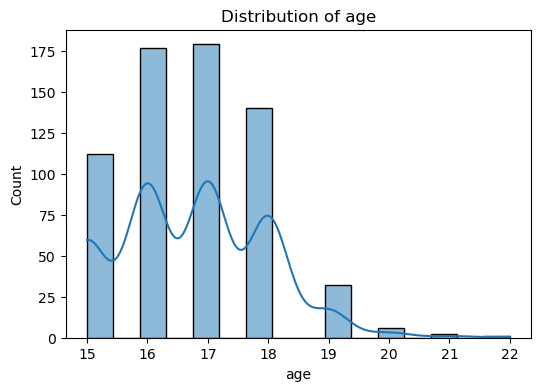

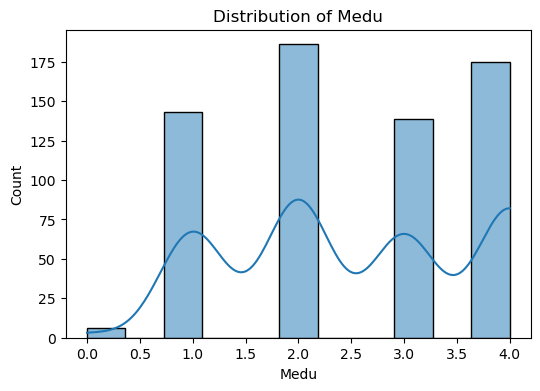

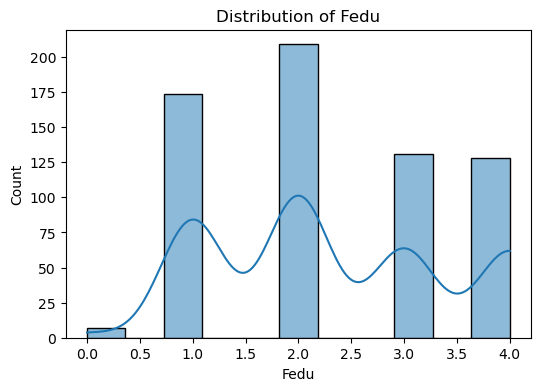

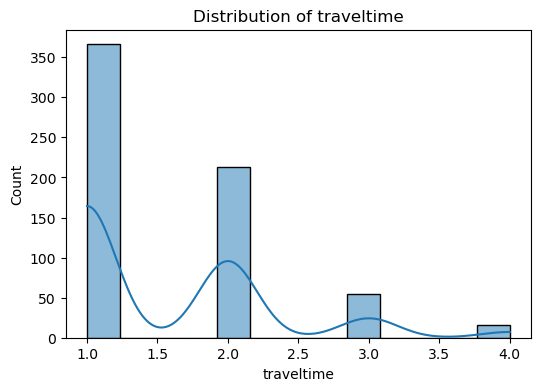

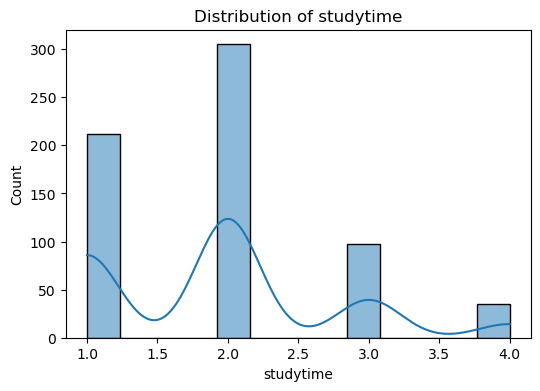

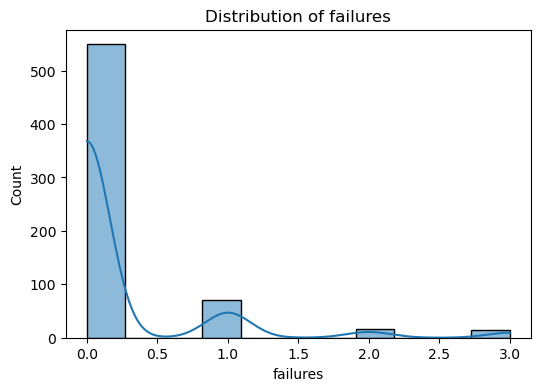

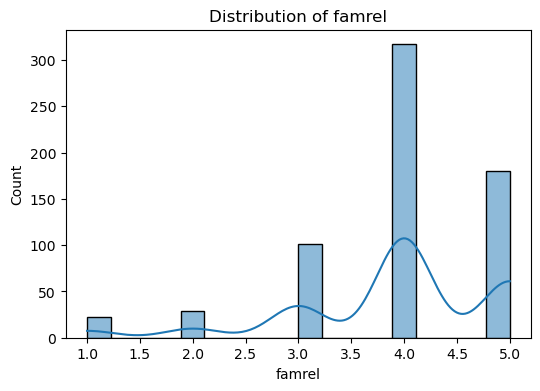

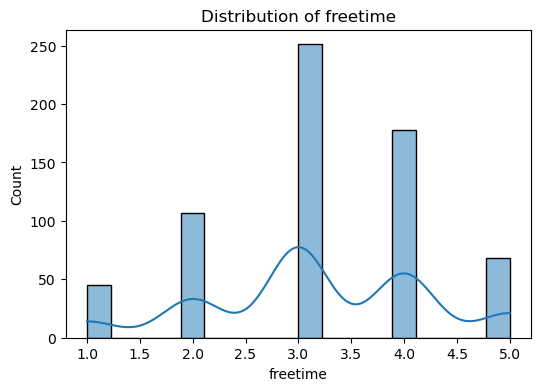

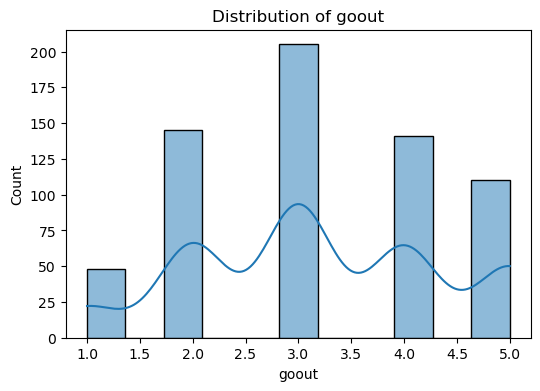

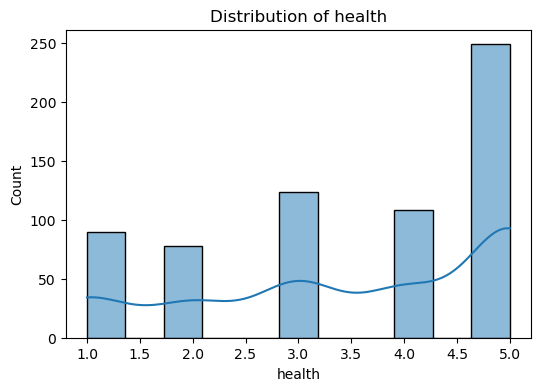

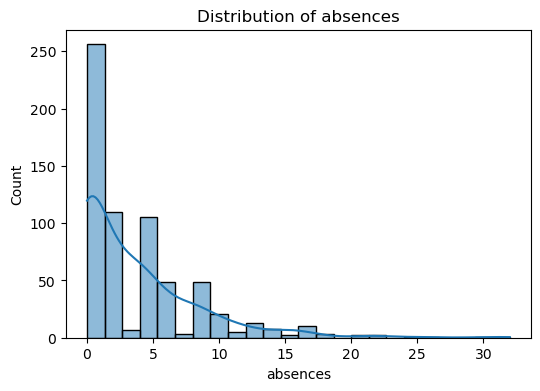

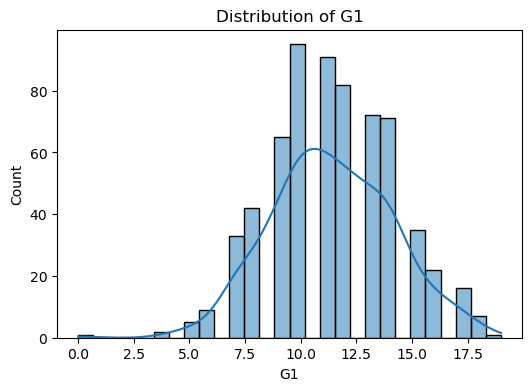

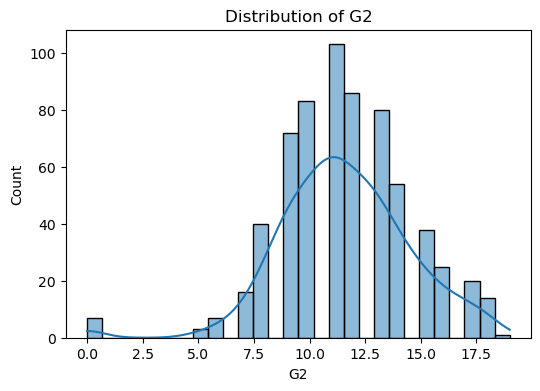

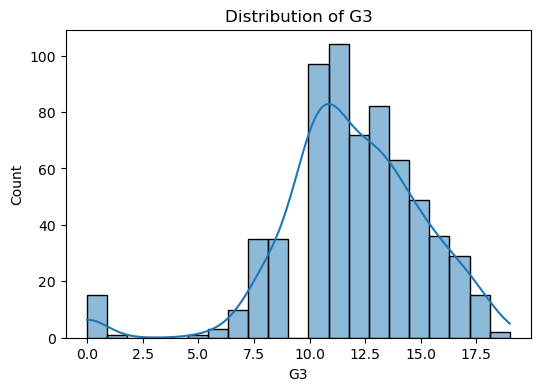

In [43]:
for cols in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(student_performance[cols],kde=True)
    plt.title(f"Distribution of {cols}")
    plt.show()
    
    

In [44]:
cat_cols=student_performance.select_dtypes(include=['object']).columns

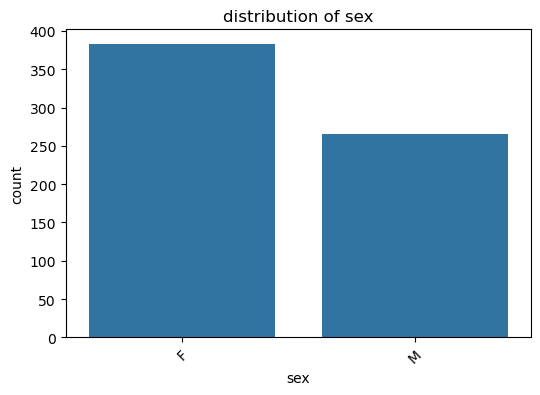

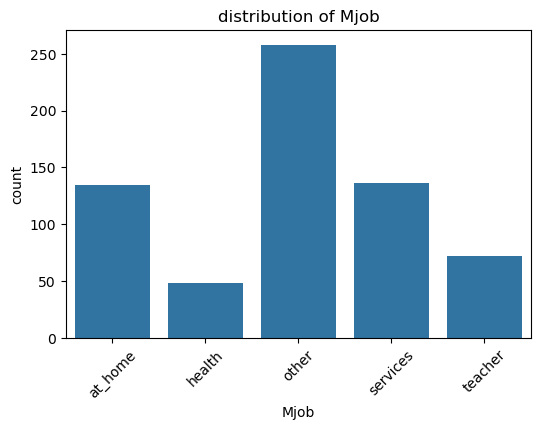

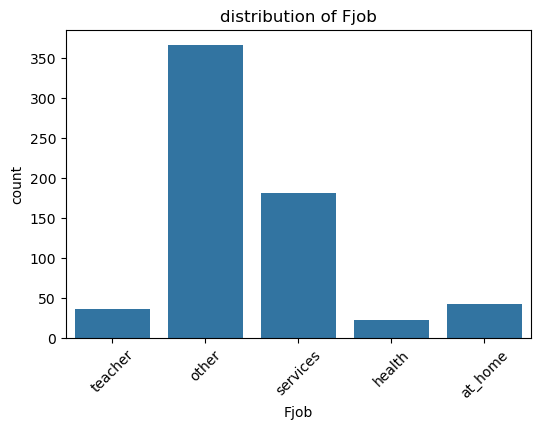

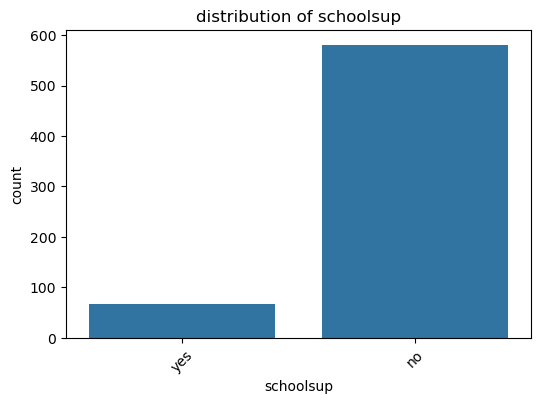

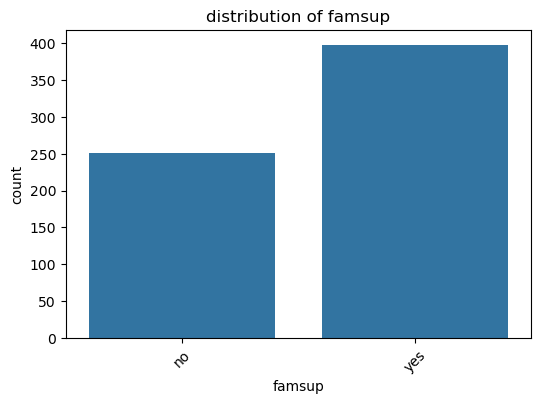

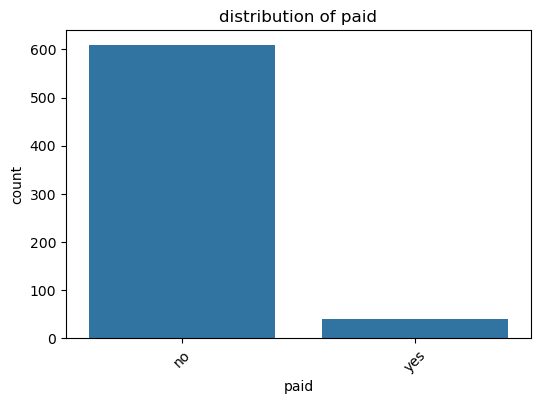

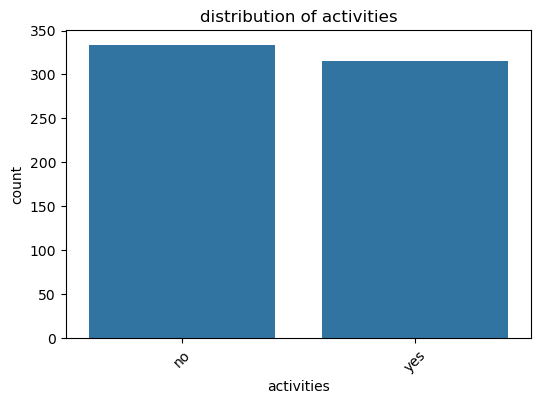

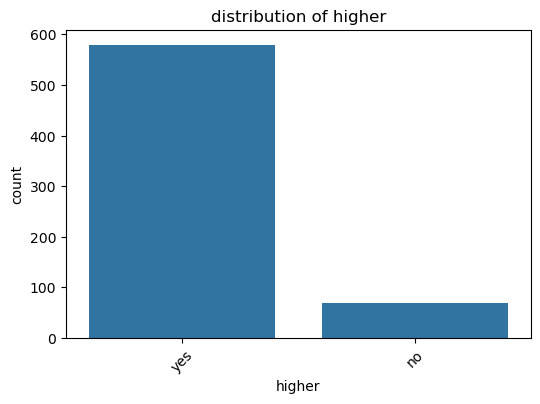

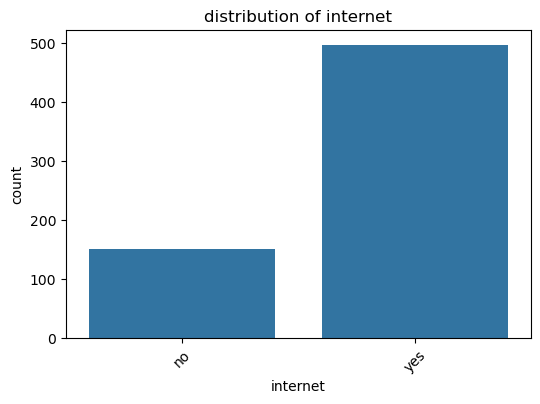

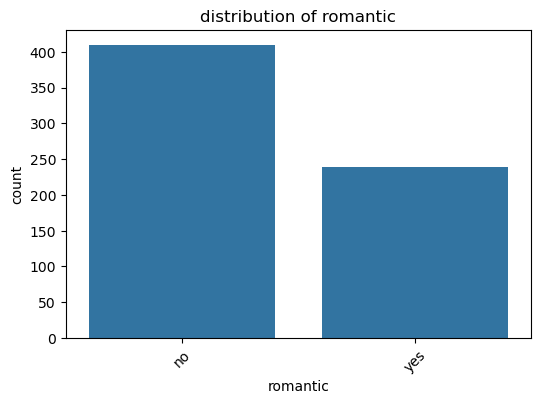

In [47]:
for cat in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=student_performance[cat])
    plt.title(f"distribution of {cat}")
    plt.xticks(rotation=45)
    plt.show()

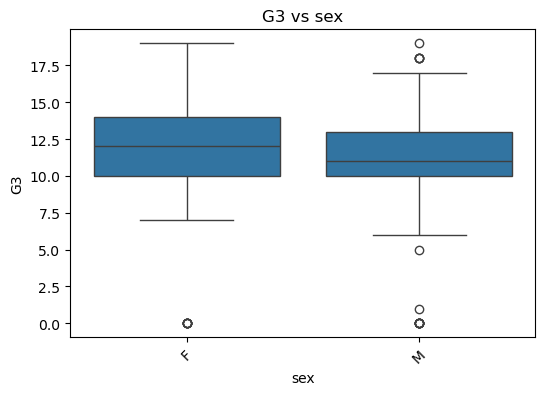

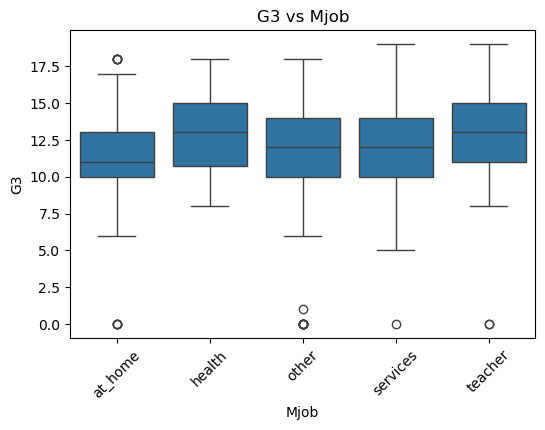

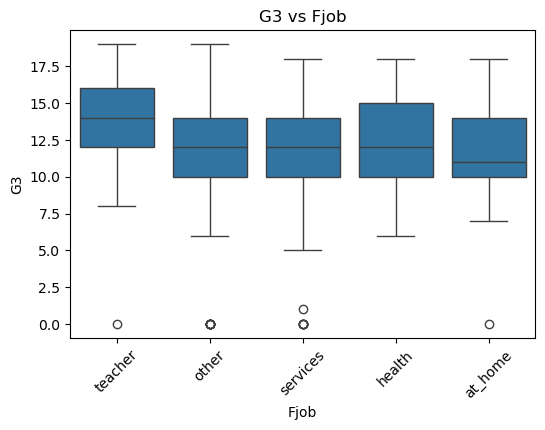

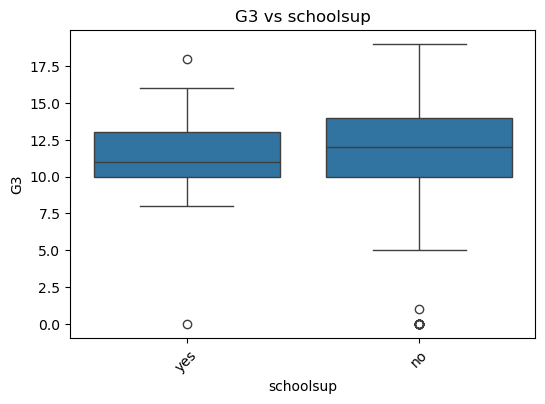

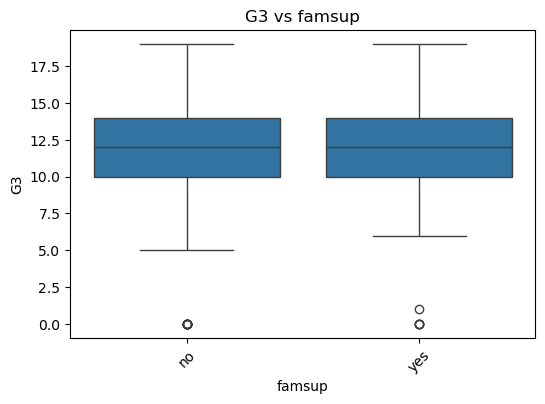

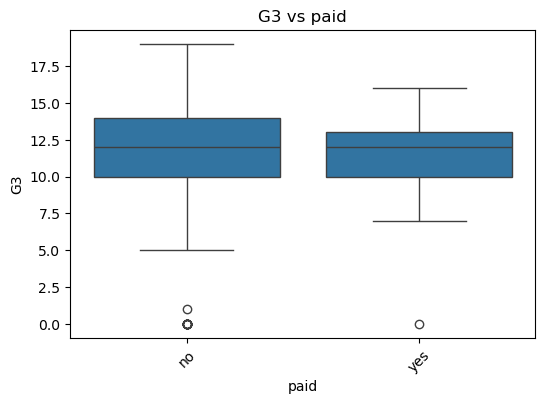

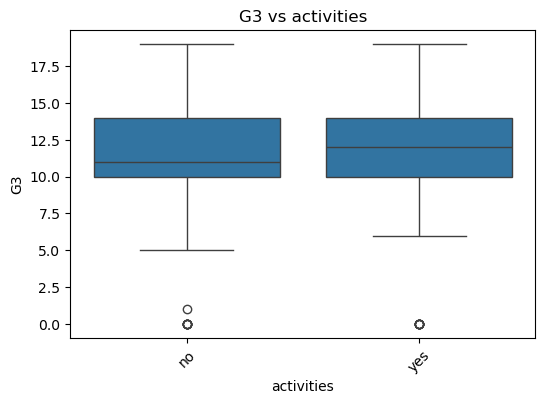

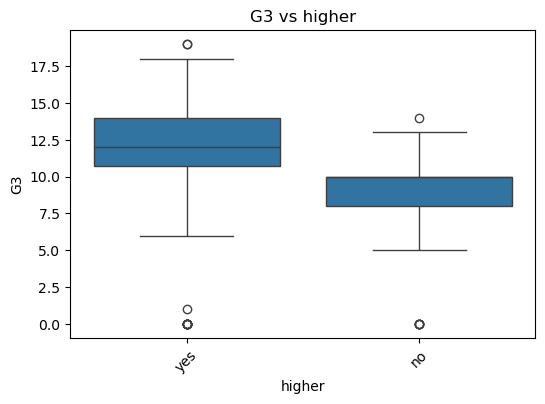

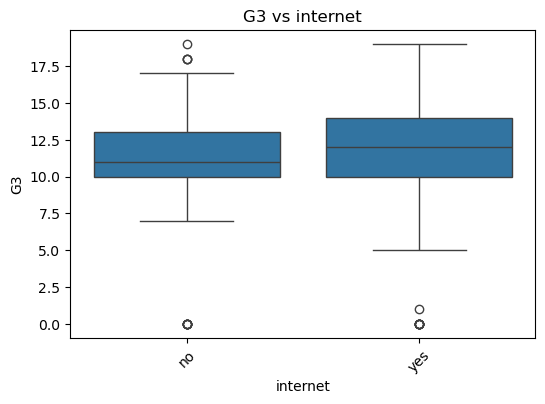

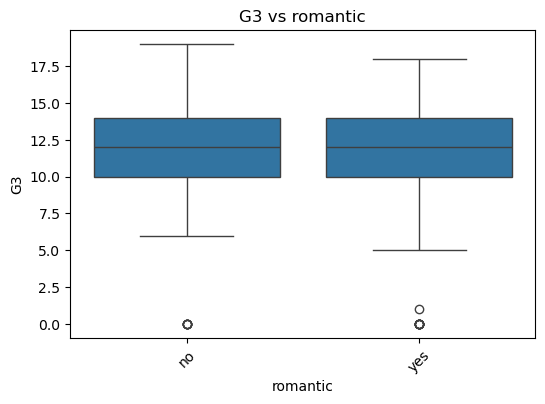

In [49]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=student_performance,x=col,y='G3')
    plt.title(f"G3 vs {col}")
    plt.xticks(rotation=45)
    plt.show()

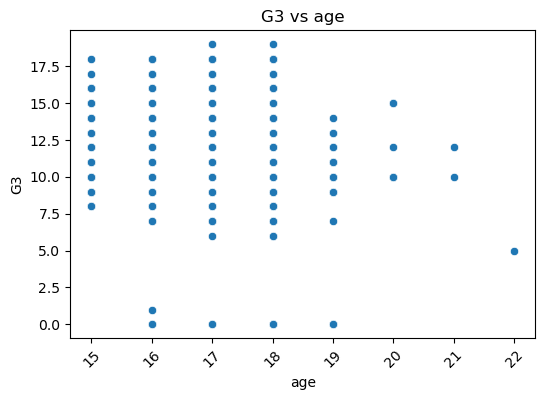

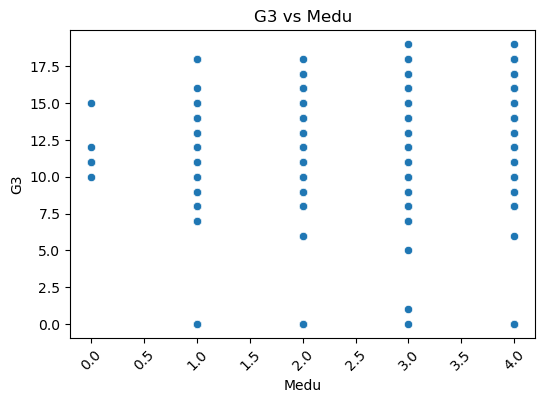

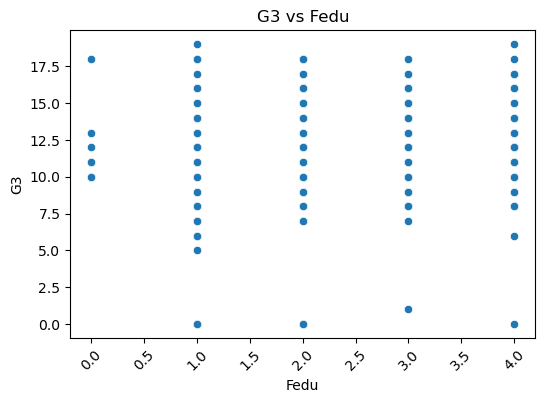

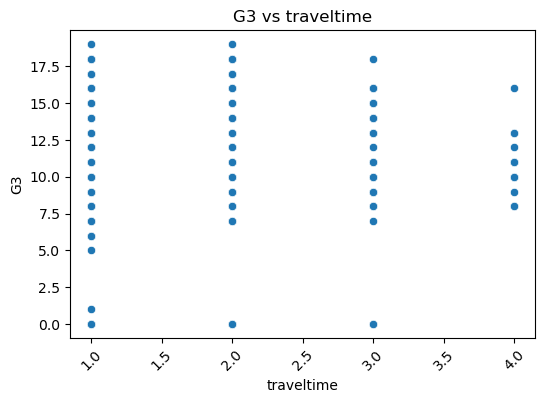

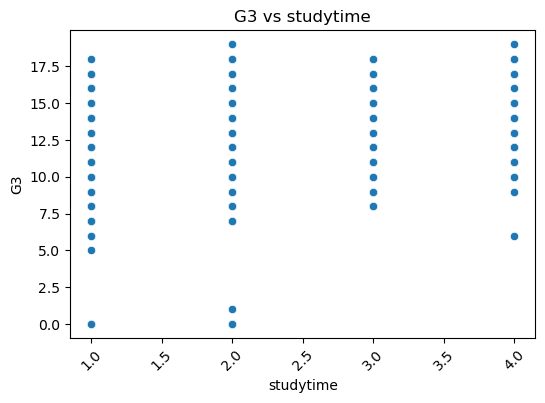

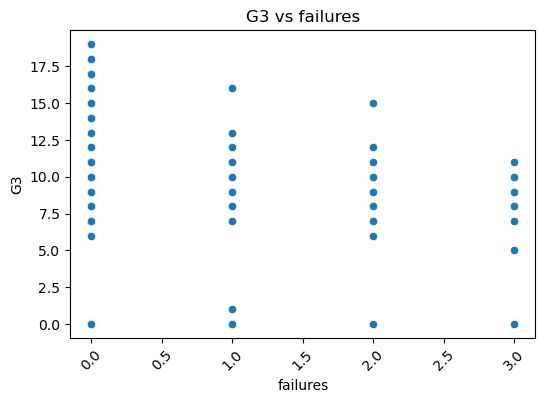

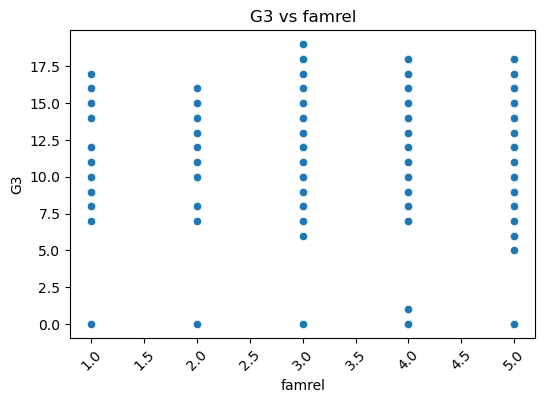

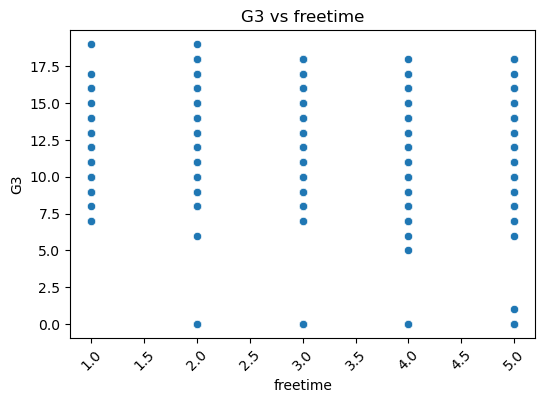

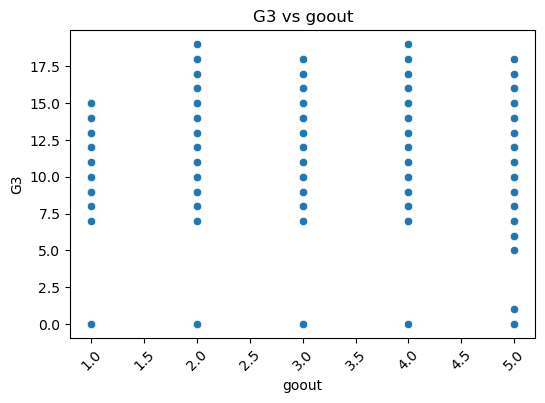

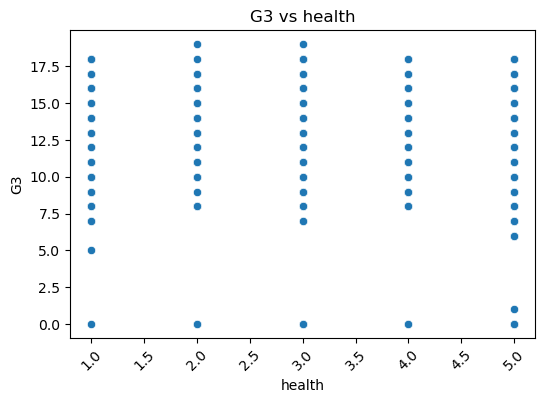

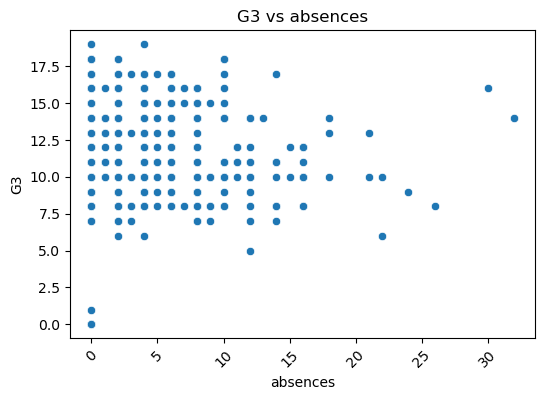

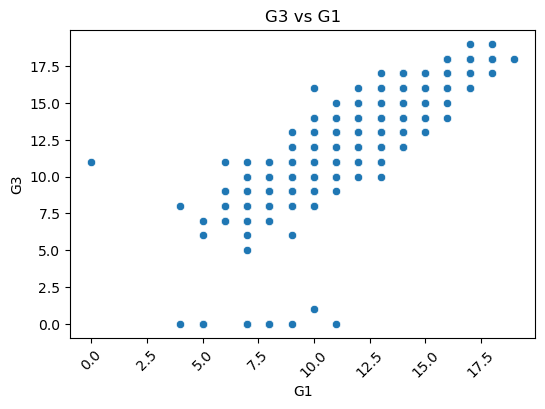

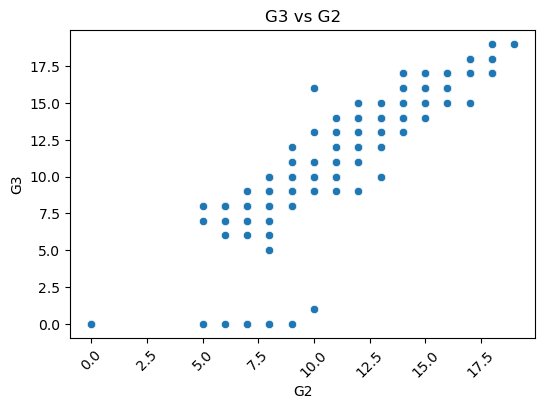

In [51]:
for col in num_cols:
    if col != 'G3':
        
      plt.figure(figsize=(6,4))
      sns.scatterplot(data=student_performance,x=col,y='G3')
      plt.title(f"G3 vs {col}")
      plt.xticks(rotation=45)
      plt.show()  
    

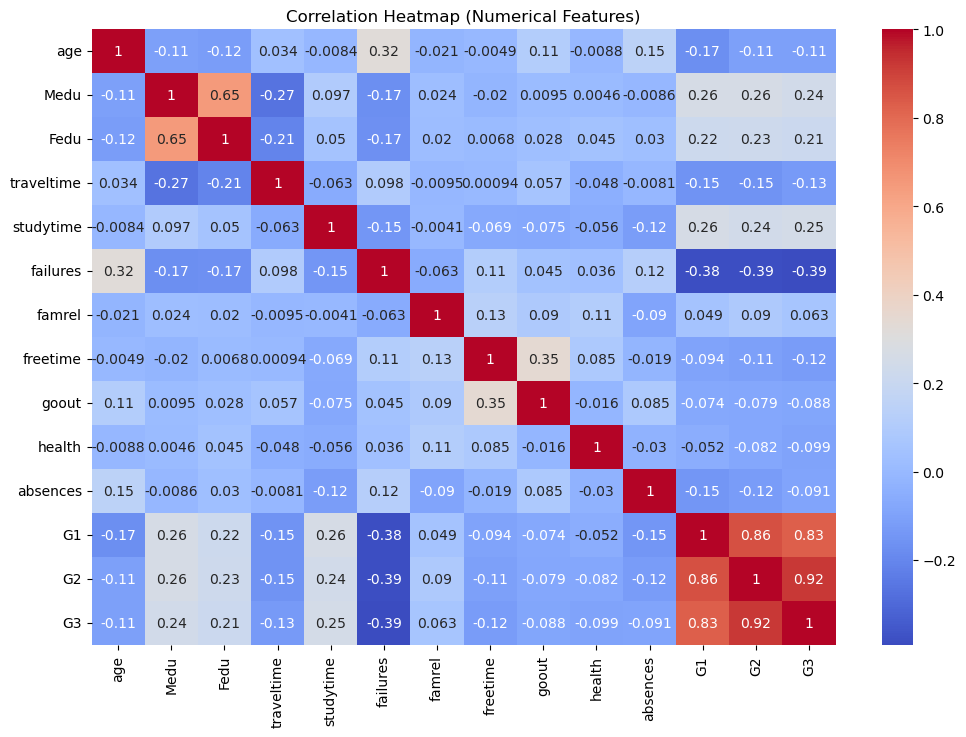

In [52]:
plt.figure(figsize=(12,8))
corr = student_performance[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()


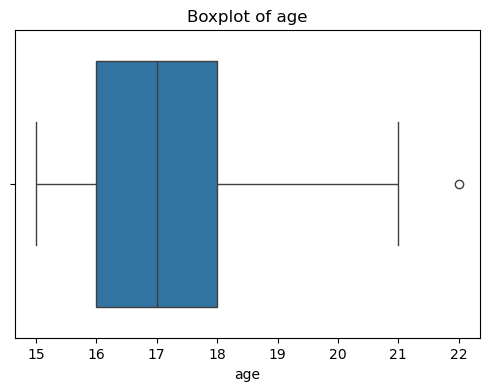

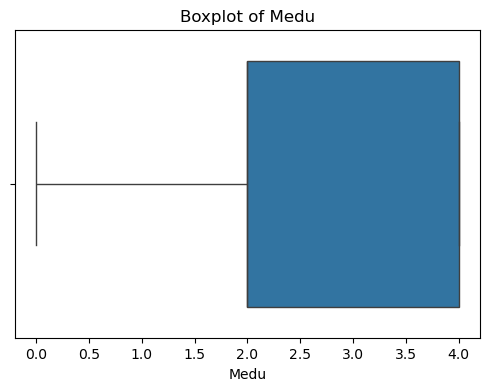

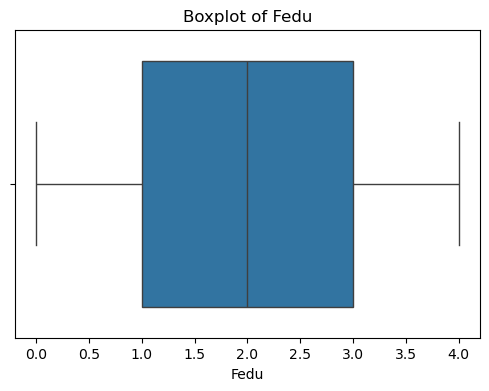

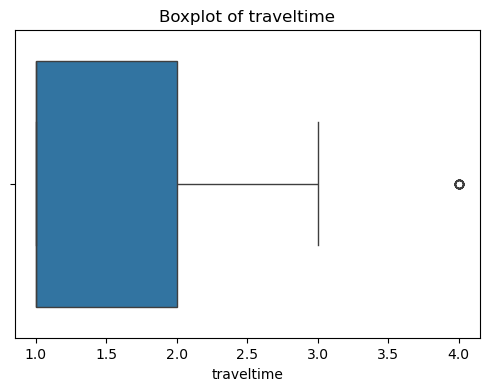

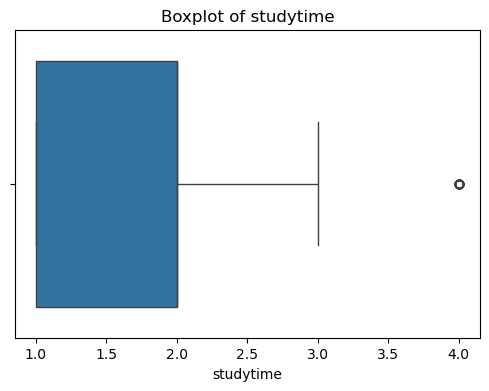

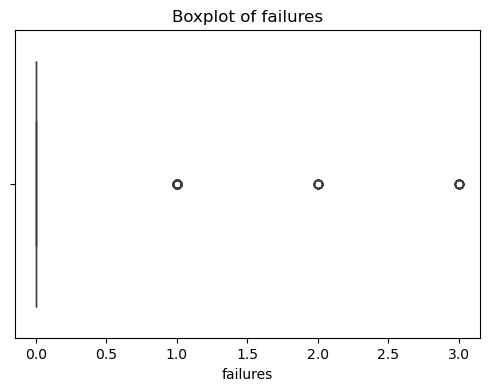

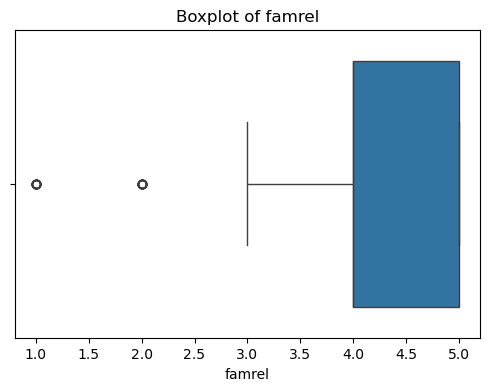

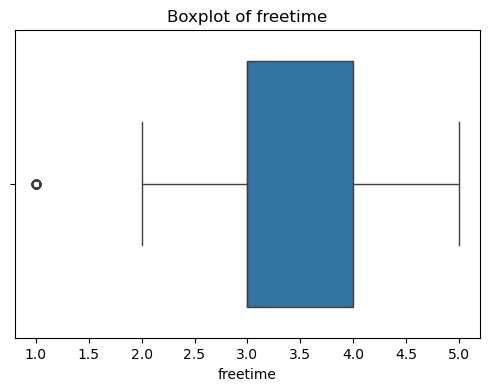

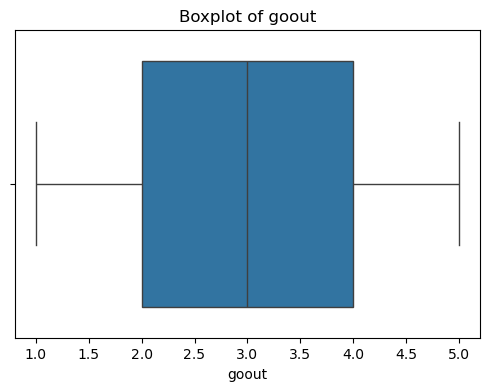

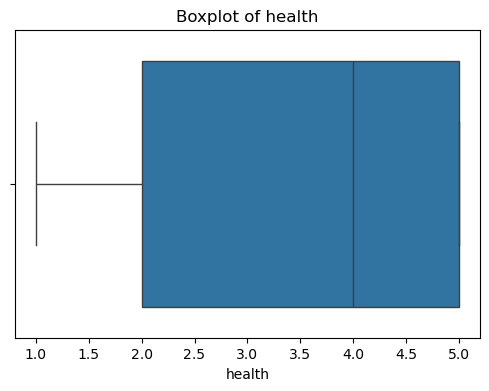

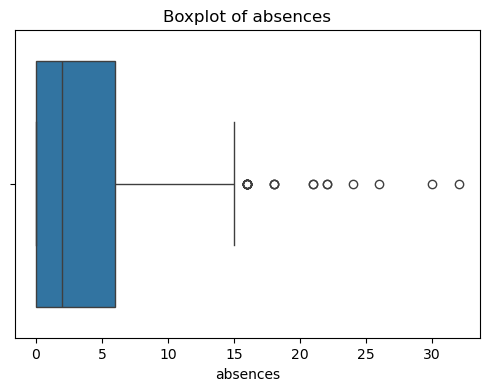

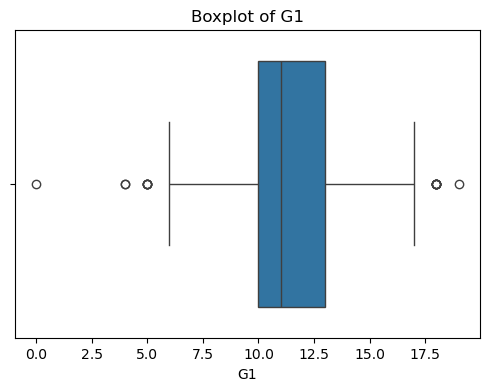

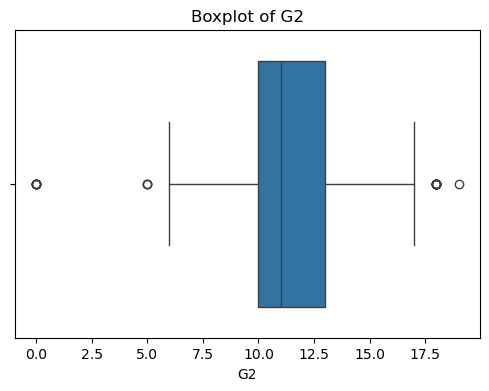

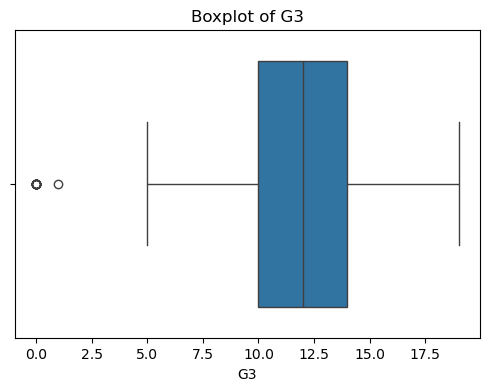

In [54]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=student_performance[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


In [56]:
student_performance.head()

,sex,age,Medu,Fedu,Mjob,Fjob,traveltime,studytime,failures,schoolsup,...,internet,romantic,famrel,freetime,goout,health,absences,G1,G2,G3
0,F,18,4,4,at_home,teacher,2,2,0,yes,...,no,no,4,3,4,3,4,0,11,11
1,F,17,1,1,at_home,other,1,2,0,no,...,yes,no,5,3,3,3,2,9,11,11
2,F,15,1,1,at_home,other,1,2,0,yes,...,yes,no,4,3,2,3,6,12,13,12
3,F,15,4,2,health,services,1,3,0,no,...,yes,yes,3,2,2,5,0,14,14,14
4,F,16,3,3,other,other,1,2,0,no,...,no,no,4,3,2,5,0,11,13,13


In [61]:
l

['sex',
 'age',
 'Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'health',
 'absences',
 'G1',
 'G2',
 'G3']

In [63]:
student_performance.duplicated().sum()

0

In [71]:
#!pip install ydata-profiling


In [73]:
#import ydata_profiling
#print("✅ ydata-profiling version:", ydata_profiling.__version__)


In [69]:
from ydata_profiling import ProfileReport

In [77]:
profile = ProfileReport(student_performance, title="Student Performance EDA Report", explorative=True)

In [89]:
file1=profile.to_file("student_performance_report.html")


Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [81]:
profile.to_file("student_performance_report.html")


Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [83]:
import webbrowser
webbrowser.open("student_performance_report.html")


True

In [103]:
student_performance.drop(columns=['G1','G2'])

,sex,age,Medu,Fedu,Mjob,Fjob,traveltime,studytime,failures,schoolsup,...,activities,higher,internet,romantic,famrel,freetime,goout,health,absences,G3
0,F,18,4,4,at_home,teacher,2,2,0,yes,...,no,yes,no,no,4,3,4,3,4,11
1,F,17,1,1,at_home,other,1,2,0,no,...,no,yes,yes,no,5,3,3,3,2,11
2,F,15,1,1,at_home,other,1,2,0,yes,...,no,yes,yes,no,4,3,2,3,6,12
3,F,15,4,2,health,services,1,3,0,no,...,yes,yes,yes,yes,3,2,2,5,0,14
4,F,16,3,3,other,other,1,2,0,no,...,no,yes,no,no,4,3,2,5,0,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,F,19,2,3,services,other,1,3,1,no,...,yes,yes,yes,no,5,4,2,5,4,10
645,F,18,3,1,teacher,services,1,2,0,no,...,no,yes,yes,no,4,3,4,1,4,16
646,F,18,1,1,other,other,2,2,0,no,...,yes,yes,no,no,1,1,1,5,6,9
647,M,17,3,1,services,services,2,1,0,no,...,no,yes,yes,no,2,4,5,2,6,10


In [105]:
import pickle as pkl

In [107]:
pkl.dump(file1, open('file1.pkl', 'wb'))


In [109]:
student_performance.shape

(649, 24)